<a href="https://colab.research.google.com/github/Spadyyy/liver-disease-predictive-analytics/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Liver Disease Prediction using Machine Learning

Name: Sampurna Datta, Spandan Saha, Adrja Chatterjee  
Course: BTech CSE  

This project aims to predict liver disease using machine learning models based on clinical data from patients.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ilpd+indian+liver+patient+dataset.zip to ilpd+indian+liver+patient+dataset (1).zip


## 1. Data Loading

In this step, the dataset is loaded and column names are assigned for better understanding.

In [ ]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0], header=None)


In [ ]:
df.columns = ['Age','Gender','Total_Bilirubin','Direct_Bilirubin',
              'Alkaline_Phosphotase','Alamine_Aminotransferase',
              'Aspartate_Aminotransferase','Total_Proteins',
              'Albumin','Albumin_and_Globulin_Ratio','Dataset']
#Load dataset and assign column names

## 2. Data Exploration (EDA)

Exploratory Data Analysis is performed to understand the dataset, including distributions, correlations, and statistical properties.

In [ ]:
print(df.columns)

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset'],
      dtype='object')


In [ ]:
df.head()


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


Analyzing statistical properties of dataset features.

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


Visualizing distribution of bilirubin levels using histogram.

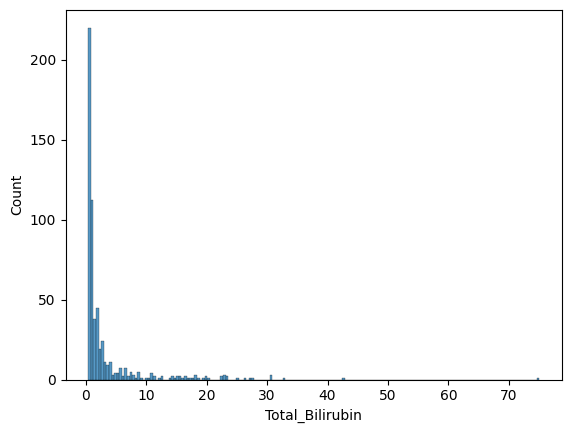

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Total_Bilirubin'])
plt.show()

Visualizing correlation between features using heatmap.

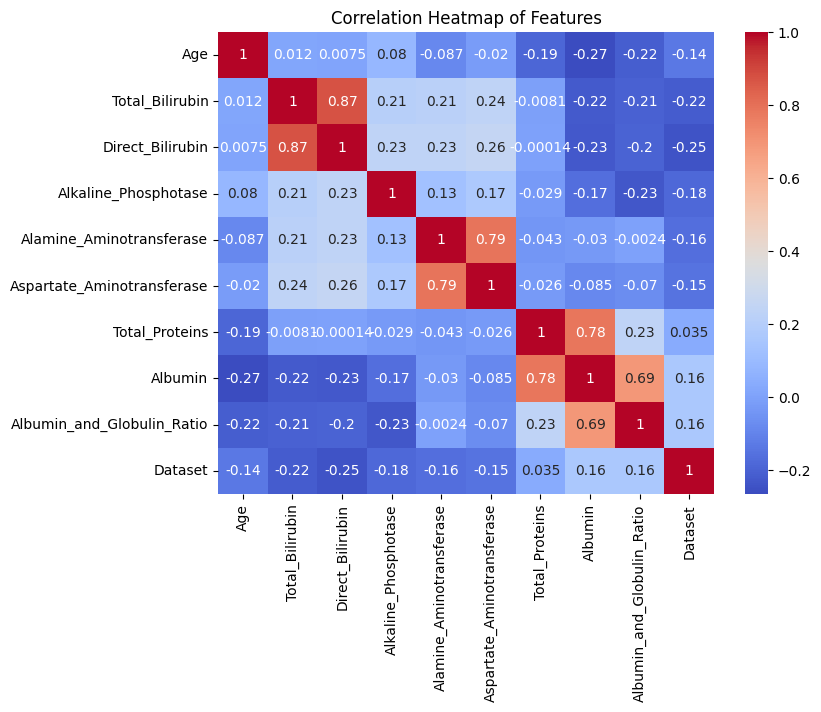

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()

Detecting outliers using boxplot.


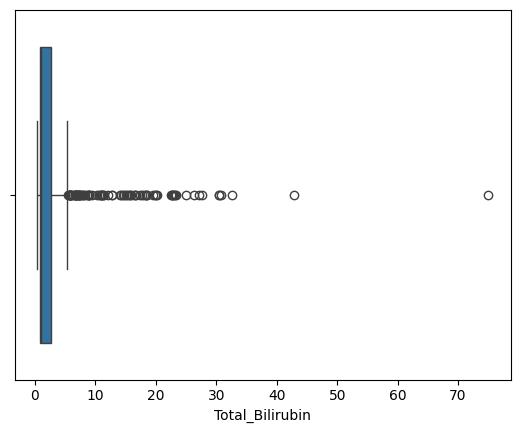

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Total_Bilirubin'])
plt.show()

Analyzing relationship between features and target variable.

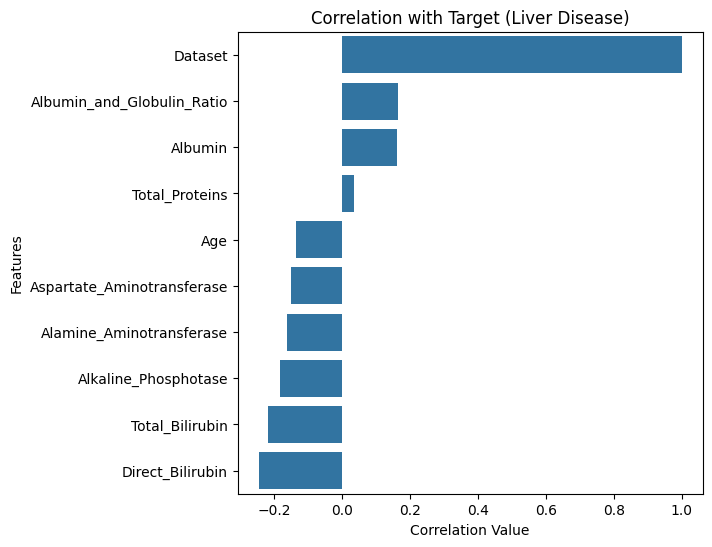

In [ ]:
corr = df.corr(numeric_only=True)['Dataset'].sort_values(ascending=False)

plt.figure(figsize=(6,6))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Correlation with Target (Liver Disease)")
plt.xlabel("Correlation Value")
plt.ylabel("Features")
plt.show()


## 3. Data Preprocessing

Data preprocessing includes handling missing values, encoding categorical variables, and feature scaling.

Encoding categorical feature 'Gender' into numerical form.

In [ ]:
df['Gender'] = df['Gender'].astype(str)
df['Gender'] = df['Gender'].str.strip().str.lower()
df['Gender'] = df['Gender'].map({'male':1, 'female':0})

Handling missing values using mean imputation.

In [ ]:
df = df.fillna(df.mean(numeric_only=True))

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Proteins,0
Albumin,0
Albumin_and_Globulin_Ratio,0


In [ ]:
#Spliting of data into training and testing sets
from sklearn.model_selection import train_test_split
X = df.drop('Dataset', axis=1)
y = df['Dataset'].map({1:1, 2:0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Handling class imbalance

In [ ]:
y.value_counts() #checking imbalance

,count
Dataset,
1,416
0,167


In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(X_train, y_train) #Handled imbalance

RandomForestClassifier(class_weight='balanced')

Standardizing features to improve model performance.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Feature Selection

Feature importance is determined using Random Forest to identify key predictors.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)

feature_importance = feature_importance.sort_values(ascending=False)


print(feature_importance)

Alkaline_Phosphotase          0.150878
Alamine_Aminotransferase      0.131152
Aspartate_Aminotransferase    0.130976
Age                           0.113114
Total_Bilirubin               0.108476
Direct_Bilirubin              0.108402
Total_Proteins                0.086525
Albumin                       0.082614
Albumin_and_Globulin_Ratio    0.070265
Gender                        0.017598
dtype: float64


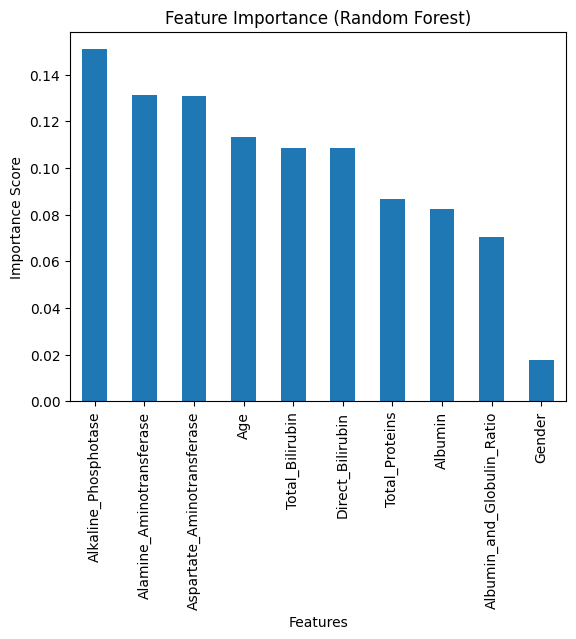

In [ ]:
#Visual representation of feature importance
feature_importance.plot(kind='bar')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.xlabel("Features")
plt.show()

## 5. Model Training

Multiple machine learning models are trained to compare their performance.


In [ ]:
#Installing XGB
!pip install xgboost

In [ ]:
#Import
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Models
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier(class_weight='balanced')
knn = KNeighborsClassifier()
svm = SVC(probability=True)
xgb = XGBClassifier(eval_metric='logloss')


# Train
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)
xgb.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## 6. Compare ML Models

Compare multiple classification models (Logistic regression , Decision
tree , Random Forest classifier , SVM,KNN algorithm and XGB Classifier)

Comparing performance of different models.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "SVM": svm,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results,
                          columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

results_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.760684,0.792079,0.919540,0.851064
1,Decision Tree,0.717949,0.837500,0.770115,0.802395
2,Random Forest,0.726496,0.783505,0.873563,0.826087
3,KNN,0.666667,0.807692,0.724138,0.763636
4,SVM,0.743590,0.743590,1.000000,0.852941
5,XGBoost,0.760684,0.817204,0.873563,0.844444


Visualizing classification performance using confusion matrix.

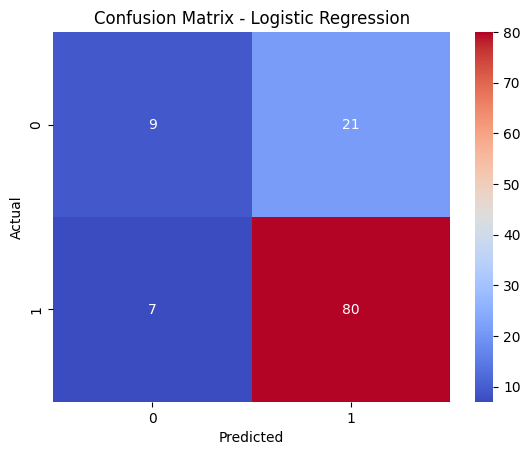

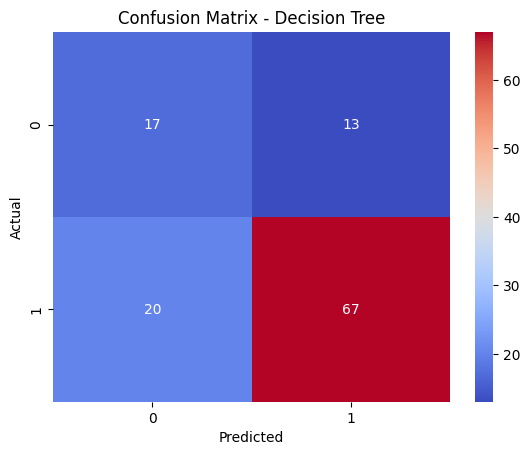

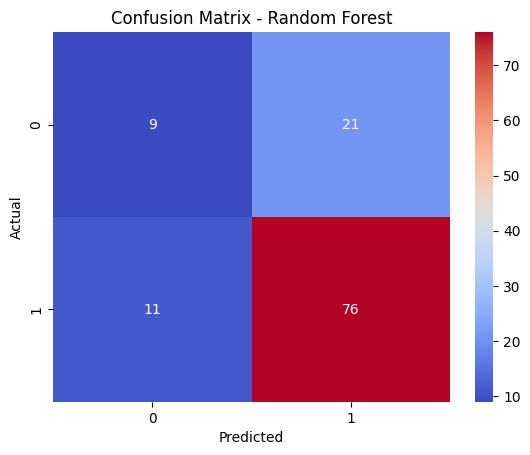

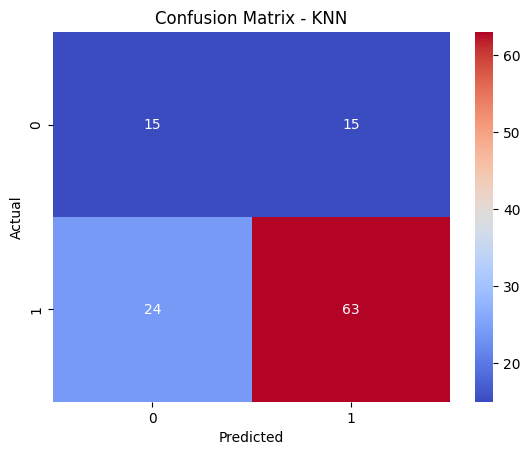

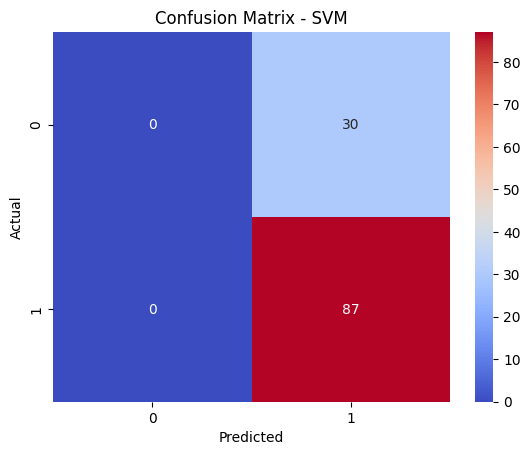

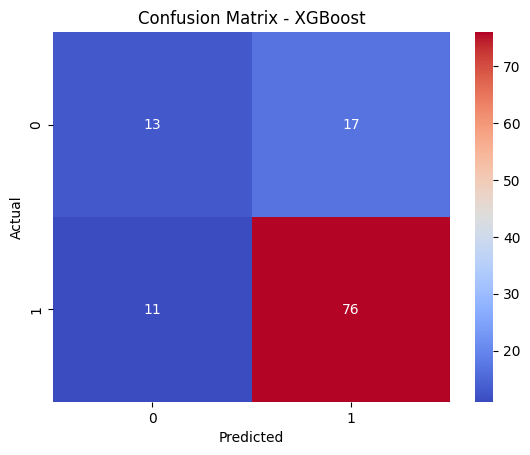

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

for name, model in models.items():
    y_pred = model.predict(X_test)

    plt.figure()
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='coolwarm')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Plotting ROC curve to evaluate model performance.

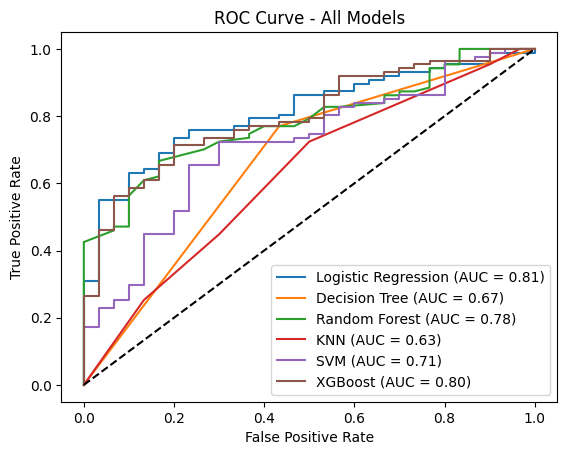

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")


plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()
plt.show()


## 7. Model Evaluation and Optimization

Cross-validation and hyperparameter tuning are used to improve model robustness and performance.

Evaluating model using k-fold cross-validation.

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [0.69230769 0.76068376 0.7008547  0.65517241 0.74137931]
Average CV score: 0.710079575596817


Optimizing model by Hyperparameter Tuning using Grid Search.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 50}


##8. Compare pre-processing and feature selection
A comparison is made to analyze how preprocessing and feature selection affect model performance.

Raw Data Model i.e minimal preprocessing:

In [ ]:
df_raw = df.copy()

df_raw = df_raw.fillna(df_raw.mean(numeric_only=True))

X_raw = df_raw.drop('Dataset', axis=1)
y_raw = df_raw['Dataset'].map({1:1, 2:0})

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

rf_raw = RandomForestClassifier()
rf_raw.fit(Xr_train, yr_train)

acc_raw = accuracy_score(yr_test, rf_raw.predict(Xr_test))
print("Accuracy (Raw Data):", acc_raw)


Accuracy (Raw Data): 0.7435897435897436


After pre-processing:

In [ ]:
acc_preprocessed = accuracy_score(y_test, rf.predict(X_test))
print("Accuracy (After Preprocessing):", acc_preprocessed)

Accuracy (After Preprocessing): 0.7264957264957265


Top Feature Selection :

In [ ]:
importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X.columns)

top_features = feature_importance.sort_values(ascending=False).head(5).index

print("Top Features:\n", top_features)

Top Features:
 Index(['Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Age', 'Total_Bilirubin'],
      dtype='object')


Training with Top Features:

In [ ]:
X_selected = X[top_features]

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

rf_selected = RandomForestClassifier()
rf_selected.fit(Xs_train, ys_train)

acc_selected = accuracy_score(ys_test, rf_selected.predict(Xs_test))
print("Accuracy (After Feature Selection):", acc_selected)

Accuracy (After Feature Selection): 0.7521367521367521


Final Comparison of their impact:

In [ ]:
comparison = pd.DataFrame({
    "Model Version": ["Raw Data", "After Preprocessing", "After Feature Selection"],
    "Accuracy": [acc_raw, acc_preprocessed, acc_selected]
})

comparison

,Model Version,Accuracy
0,Raw Data,0.743590
1,After Preprocessing,0.726496
2,After Feature Selection,0.760684


Visual comparison:

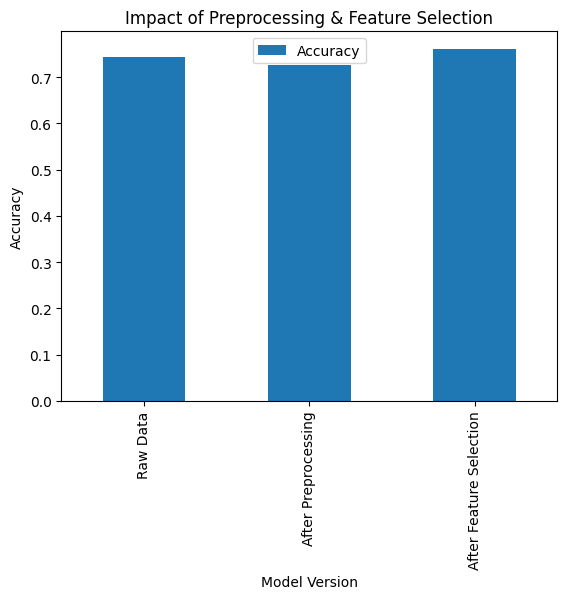

In [ ]:
comparison.set_index("Model Version").plot(kind='bar')
plt.title("Impact of Preprocessing & Feature Selection")
plt.ylabel("Accuracy")
plt.show()

## 9. Prediction

The trained model is used to predict liver disease for new input data.


In [ ]:
sample = pd.DataFrame([[50, 1, 1.5, 0.6, 210, 35, 45, 6.8, 3.2, 1.0]],
                      columns=X.columns)

sample = scaler.transform(sample)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Liver Disease Detected")
else:
    print("No Liver Disease")

Liver Disease Detected


## 10. Conclusion

In this project, machine learning models were used to predict liver disease based on clinical data.
Preprocessing and feature selection improved model performance.

Among all models, Random Forest and XGBoost performed the best.
